Libraries and functions

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,  Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit

Data import and DataFrame generation

In [167]:
path = Path() / "Dataset3_PortfolioReplicaStrategy.xlsx"

data = pd.read_excel(path)
data = data.set_index('Ticker')
data = data.sort_index()

data.head()

,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Ticker,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


Data preparation

In [168]:
index_components = {"MXWO" : 0.25,
                    "MXWD" : 0,
                    "LEGATRUU" : 0.25,
                    "HFRXGL" : 0.5}

component_returns = data[list(index_components.keys())].pct_change().dropna()

Y = sum(component_returns[col] * w for col, w in index_components.items())
Y.name = 'Monster_Index'

futures = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

X = data[futures].pct_change().dropna() # Futures matrix

common_dates = X.index.intersection(Y.index) # Riallineo i dataset
X = X.loc[common_dates]
Y = Y.loc[common_dates]

Train-Test split and futures returnstest standardization


In [169]:
split_date = '2018-12-31'

X_train = X.loc[:split_date]
X_test = X.loc[split_date:]
Y_train = Y.loc[:split_date]
Y_test = Y.loc[split_date:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Correlation analysis

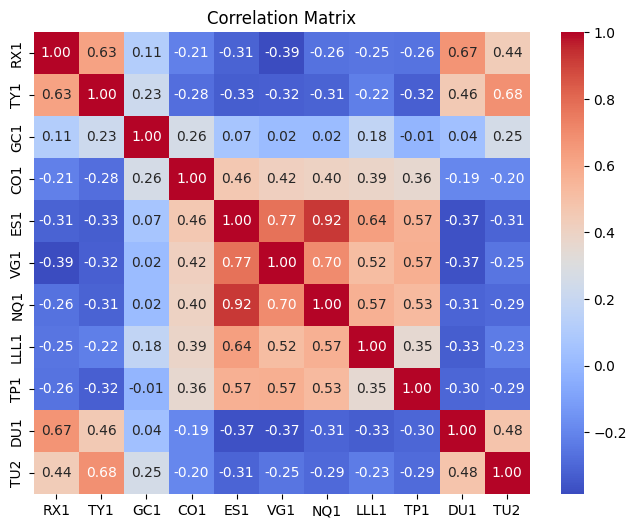

In [170]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

corr_matrix = X_train_scaled_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Droppo indice NQ1

In [171]:
nq1_idx = list(X_train.columns).index('NQ1')

X_train_scaled = np.delete(X_train_scaled, nq1_idx, axis=1)
X_test_scaled  = np.delete(X_test_scaled, nq1_idx, axis=1)

X_train = X_train.drop(columns=['NQ1'])
X_test  = X_test.drop(columns=['NQ1'])

print("Colonne rimanenti:", X_train.columns.tolist())
print("Shape X_train_scaled:", X_train_scaled.shape)

Colonne rimanenti: ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'LLL1', 'TP1', 'DU1', 'TU2']
Shape X_train_scaled: (583, 10)


---------------------------

OLS


In [172]:
rolling_window = 52

predicted_returns_train = []
weights_train = []
dates_train = []

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train.iloc[i : i + rolling_window]

    model = LinearRegression(fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_train.append(pred)
    weights_train.append(model.coef_)
    dates_train.append(Y_train.index[i + rolling_window])

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all = pd.concat([Y_train, Y_test])

predicted_returns_test = []
weights_test           = []
dates_test             = []

for j in range(len(X_train_scaled), len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all.iloc[j - rolling_window : j]

    model = LinearRegression(fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_all_scaled[j + 1].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_test.append(pred)
    weights_test.append(model.coef_)
    dates_test.append(Y_all.index[j + 1])

Y_pred_train = pd.Series(predicted_returns_train, index=dates_train)
Y_pred_test = pd.Series(predicted_returns_test, index=dates_test)

Metriche

In [173]:
def annual_return(returns):
    ann_ret = returns.mean() * 52
    return ann_ret

def volatility(returns):
    vol = np.std(returns, ddof=1) * np.sqrt(52)
    return vol

def tracking_error_volatility(returns_replica, returns_target):
    tev = np.std(returns_replica - returns_target, ddof=1) * np.sqrt(52)
    return tev

def sharpe_ratio(returns):
    sharpe = annual_return(returns) / volatility(returns)
    return sharpe

def max_drawdown(returns):
    cumulative  = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

def gross_exposure(weights_history):
    weights_df = pd.DataFrame(weights_history)
    return weights_df.abs().sum(axis=1).mean()

def correlation(returns_replica, returns_target):
    corr = returns_replica.corr(returns_target)
    return corr

def information_ratio(returns_replica, returns_target):
    active_returns = returns_replica - returns_target
    
    excess_return = active_returns.mean() * 52
    tracking_error = active_returns.std(ddof=1) * np.sqrt(52)
    
    if tracking_error == 0:
        return np.nan
    
    return excess_return / tracking_error

In [174]:
Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned) * 100, 
                volatility(Y_test_aligned) * 100, 
                sharpe_ratio(Y_test_aligned),
                max_drawdown(Y_test_aligned) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test) * 100, 
                volatility(Y_pred_test) * 100, 
                sharpe_ratio(Y_pred_test),
                max_drawdown(Y_pred_test) * 100,
                tracking_error_volatility(Y_pred_test, Y_test_aligned) * 100,
                gross_exposure(weights_test),
                information_ratio(Y_pred_test, Y_test_aligned),
                correlation(Y_pred_test, Y_test_aligned)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,12.088923
1,Annualized volatility,7.148066,5.822574
2,Sharpe ratio,1.469359,2.076216
3,Max Drawdown,-13.388949,-7.383185
4,Tracking Error Volatility,N/A,4.472291
5,Gross Exposure,N/A,0.211760
6,Information Ratio,N/A,0.354595
7,Correlation,N/A,0.780822


Plot dei return dei test set: comparazione Target vs Replica

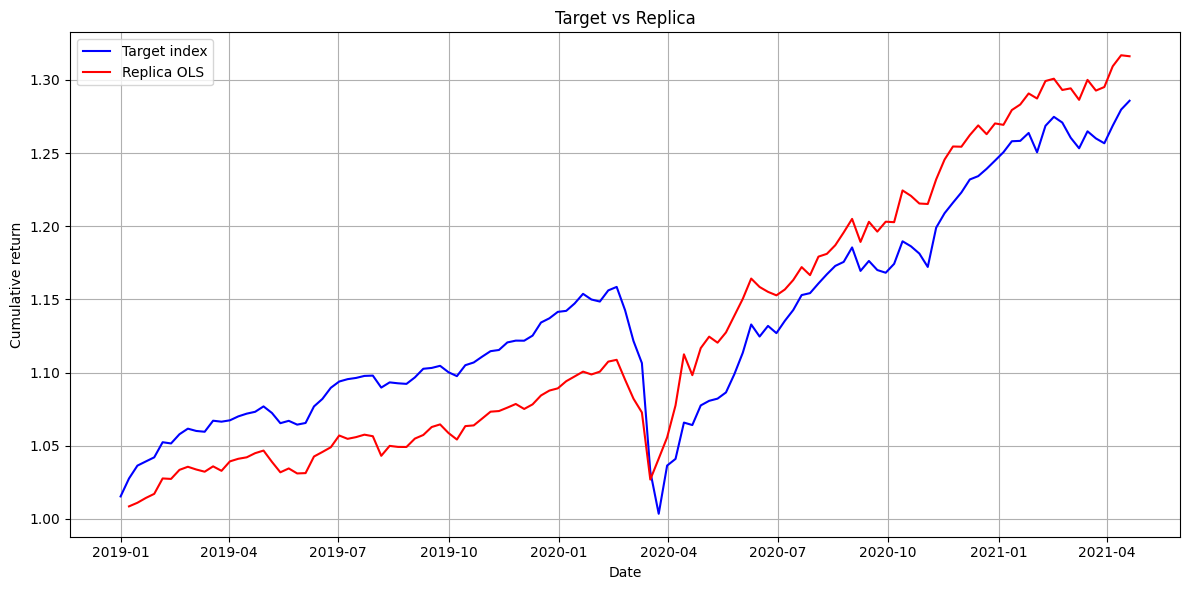

In [175]:
plt.figure(figsize=(12, 6))
plt.plot((1 + Y_test).cumprod(), label='Target index', color='blue')
plt.plot((1 + Y_pred_test).cumprod(), label='Replica OLS', color='red')
plt.title('Target vs Replica')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--------------------

RIDGE

Scaling di Y - Necessario per ottenere un termine di penalizzazione corretto

In [176]:
scaler_Y = StandardScaler()

Y_train_scaled = pd.Series(
    scaler_Y.fit_transform(Y_train.values.reshape(-1, 1)).flatten(),
    index=Y_train.index
)

Y_test_scaled = pd.Series(
    scaler_Y.transform(Y_test.values.reshape(-1, 1)).flatten(),
    index=Y_test.index
)

Sweep su alpha con time-series cross validation

In [177]:
alphas_ridge = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
tscv_ridge = TimeSeriesSplit(n_splits=3)

model_cv_ridge = RidgeCV(alphas=alphas_ridge, cv=tscv_ridge, fit_intercept=False)
model_cv_ridge.fit(X_train_scaled, Y_train_scaled)

best_alpha_ridge = model_cv_ridge.alpha_
print(f"Best alpha: {best_alpha_ridge}")

Best alpha: 10.0


In [178]:
rolling_window = 52

predicted_returns_train_ridge = []
weights_train_ridge = []
dates_train_ridge = []

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train_scaled.iloc[i : i + rolling_window]

    model = Ridge(alpha=best_alpha_ridge, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_train_ridge.append(pred)
    weights_train_ridge.append(model.coef_)
    dates_train_ridge.append(Y_train_scaled.index[i + rolling_window])

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all_scaled = pd.concat([Y_train_scaled, Y_test_scaled])

predicted_returns_test_ridge = []
weights_test_ridge           = []
dates_test_ridge             = []

for j in range(len(X_train_scaled), len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all_scaled.iloc[j - rolling_window : j]

    model = Ridge(alpha=best_alpha_ridge, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_all_scaled[j + 1].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_test_ridge.append(pred)
    weights_test_ridge.append(model.coef_)
    dates_test_ridge.append(Y_all_scaled.index[j + 1])

Y_pred_train_ridge = pd.Series(
    scaler_Y.inverse_transform(
        pd.Series(predicted_returns_train_ridge).values.reshape(-1, 1)
    ).flatten(),
    index=dates_train_ridge
)
Y_pred_test_ridge = pd.Series(
    scaler_Y.inverse_transform(
        pd.Series(predicted_returns_test_ridge).values.reshape(-1, 1)
    ).flatten(),
    index=dates_test_ridge
)

In [179]:
Y_test_aligned_ridge = Y_test.loc[Y_pred_test_ridge.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned_ridge) * 100, 
                volatility(Y_test_aligned_ridge) * 100, 
                sharpe_ratio(Y_test_aligned_ridge),
                max_drawdown(Y_test_aligned_ridge) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_ridge) * 100, 
                volatility(Y_pred_test_ridge) * 100, 
                sharpe_ratio(Y_pred_test_ridge),
                max_drawdown(Y_pred_test_ridge) * 100,
                tracking_error_volatility(Y_pred_test_ridge, Y_test_aligned_ridge) * 100,
                gross_exposure(weights_test_ridge),
                information_ratio(Y_pred_test_ridge, Y_test_aligned_ridge),
                correlation(Y_pred_test_ridge, Y_test_aligned_ridge)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,7.412241
1,Annualized volatility,7.148066,4.963218
2,Sharpe ratio,1.469359,1.493435
3,Max Drawdown,-13.388949,-6.653917
4,Tracking Error Volatility,N/A,4.506999
5,Gross Exposure,N/A,1.453487
6,Information Ratio,N/A,-0.685785
7,Correlation,N/A,0.780995


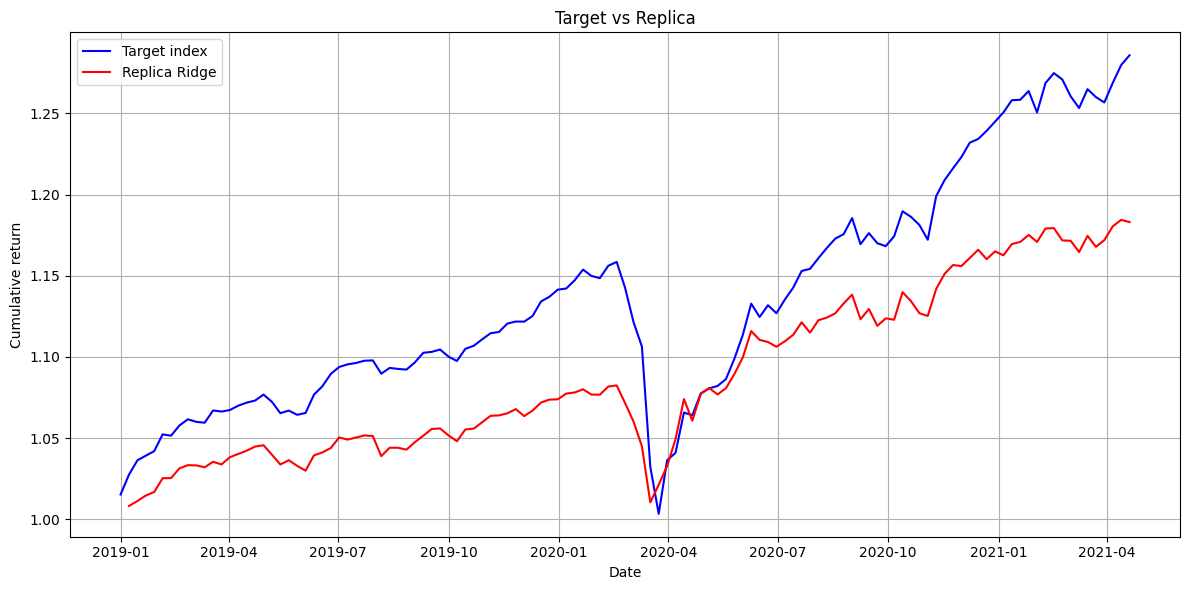

In [180]:
plt.figure(figsize=(12, 6))
plt.plot((1 + Y_test).cumprod(), label='Target index', color='blue')
plt.plot((1 + Y_pred_test_ridge).cumprod(), label='Replica Ridge', color='red')
plt.title('Target vs Replica')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ridge non migliora OLS perché la penalizzazione L2 comprime i pesi in modo eccessivo, riducendo la capacità replicativa del portafoglio.

Ridge penalizza tutti i coefficienti uniformemente verso zero, riducendo la gross exposure ma anche la capacità replicativa. In un problema di replicazione dove tutti gli 11 futures contribuiscono al Monster Index, questa penalizzazione indiscriminata è controproducente.

-------------------------------------

LASSO

Alpha sweep - Cross validation

In [181]:
alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
tscv_lasso = TimeSeriesSplit(n_splits=3)

model_cv_lasso = LassoCV(alphas=alphas_lasso, cv=tscv_lasso, fit_intercept=False)
model_cv_lasso.fit(X_train_scaled, Y_train_scaled)

best_alpha_lasso = model_cv_lasso.alpha_
print(f"Best alpha: {best_alpha_lasso}")

Best alpha: 0.05


Loop

In [182]:
rolling_window = 52

predicted_returns_train_lasso = []
weights_train_lasso = []
dates_train_lasso = []

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train_scaled.iloc[i : i + rolling_window]

    model = Lasso(alpha=best_alpha_lasso, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_train_lasso.append(pred)
    weights_train_lasso.append(model.coef_)
    dates_train_lasso.append(Y_train_scaled.index[i + rolling_window])

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all_scaled = pd.concat([Y_train_scaled, Y_test_scaled])

predicted_returns_test_lasso = []
weights_test_lasso           = []
dates_test_lasso             = []

for j in range(len(X_train_scaled), len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all_scaled.iloc[j - rolling_window : j]

    model = Lasso(alpha=best_alpha_lasso, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_all_scaled[j + 1].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_test_lasso.append(pred)
    weights_test_lasso.append(model.coef_)
    dates_test_lasso.append(Y_all_scaled.index[j + 1])

Y_pred_train_lasso = pd.Series(
    scaler_Y.inverse_transform(
        pd.Series(predicted_returns_train_lasso).values.reshape(-1, 1)
    ).flatten(),
    index=dates_train_lasso
)
Y_pred_test_lasso = pd.Series(
    scaler_Y.inverse_transform(
        pd.Series(predicted_returns_test_lasso).values.reshape(-1, 1)
    ).flatten(),
    index=dates_test_lasso
)

In [183]:
Y_test_aligned_lasso = Y_test.loc[Y_pred_test_lasso.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned_lasso) * 100, 
                volatility(Y_test_aligned_lasso) * 100, 
                sharpe_ratio(Y_test_aligned_lasso),
                max_drawdown(Y_test_aligned_lasso) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_lasso) * 100, 
                volatility(Y_pred_test_lasso) * 100, 
                sharpe_ratio(Y_pred_test_lasso),
                max_drawdown(Y_pred_test_lasso) * 100,
                tracking_error_volatility(Y_pred_test_lasso, Y_test_aligned_lasso) * 100,
                gross_exposure(weights_test_lasso),
                information_ratio(Y_pred_test_lasso, Y_test_aligned_lasso),
                correlation(Y_pred_test_lasso, Y_test_aligned_lasso)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,7.960418
1,Annualized volatility,7.148066,5.163722
2,Sharpe ratio,1.469359,1.541605
3,Max Drawdown,-13.388949,-5.970832
4,Tracking Error Volatility,N/A,4.301934
5,Gross Exposure,N/A,1.194033
6,Information Ratio,N/A,-0.591049
7,Correlation,N/A,0.802645


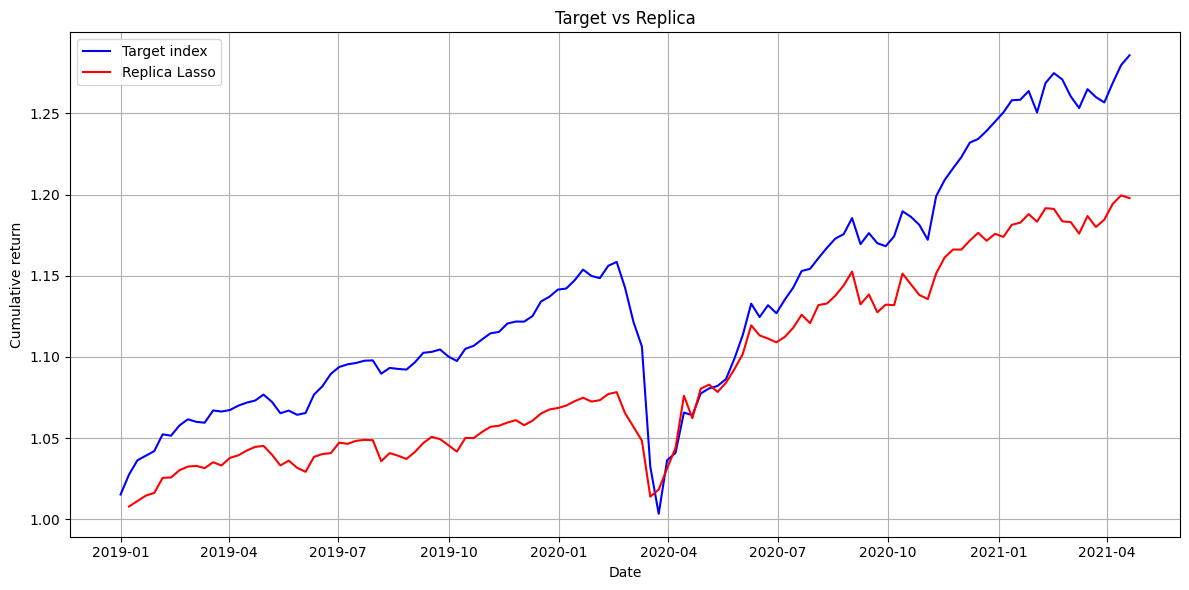

In [184]:
plt.figure(figsize=(12, 6))
plt.plot((1 + Y_test).cumprod(), label='Target index', color='blue')
plt.plot((1 + Y_pred_test_lasso).cumprod(), label='Replica Lasso', color='red')
plt.title('Target vs Replica')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Analisi temporale dei pesi

Frequenza di selezione dei futures (%):
ES1     100.00
TP1      86.67
GC1      79.17
VG1      50.00
RX1      46.67
DU1      43.33
TY1      16.67
CO1      13.33
TU2       0.83
LLL1      0.00
dtype: float64


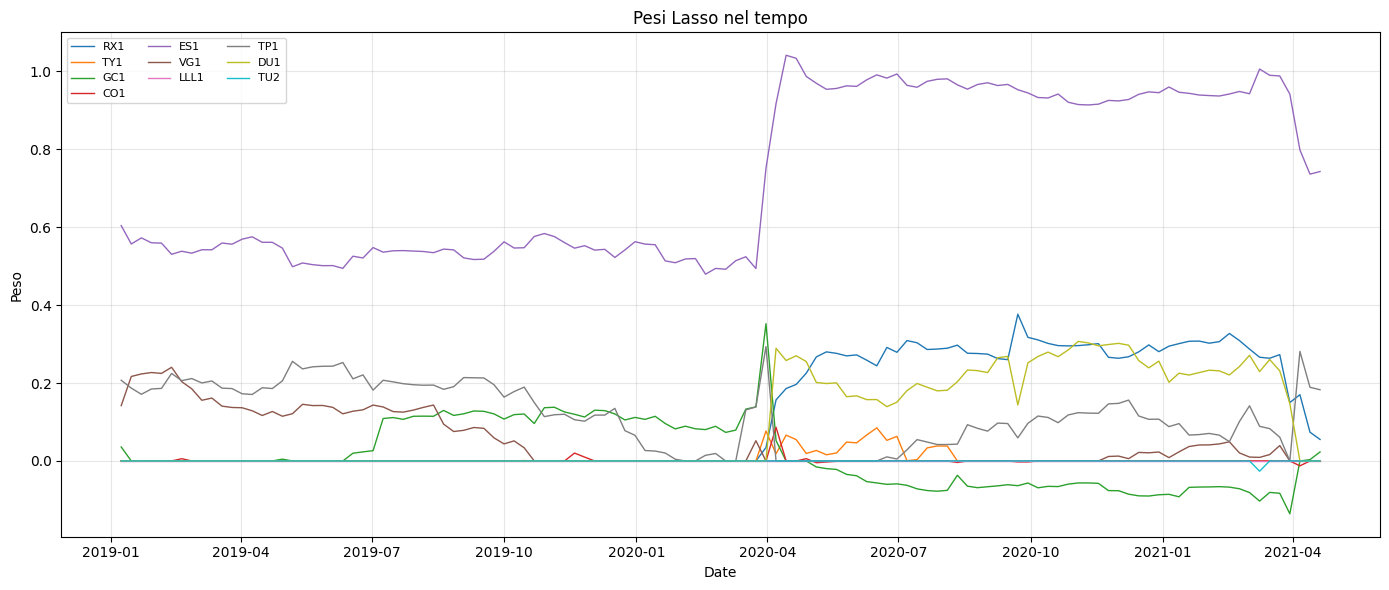

In [185]:
weights_df_lasso = pd.DataFrame(
    weights_test_lasso,
    index=dates_test_lasso,
    columns=X_train.columns
)

selection_freq = (weights_df_lasso != 0).mean() * 100
selection_freq = selection_freq.sort_values(ascending=False)

print("Frequenza di selezione dei futures (%):")
print(selection_freq.round(2))

plt.figure(figsize=(14, 6))
for col in weights_df_lasso.columns:
    plt.plot(weights_df_lasso[col], label=col, linewidth=1)
plt.title('Pesi Lasso nel tempo')
plt.xlabel('Date')
plt.ylabel('Peso')
plt.legend(fontsize=8, ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---------------------------------------

ELASTIC NET

In [186]:
alphas_elastic = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
tscv_elastic = TimeSeriesSplit(n_splits=3)

model_cv_elastic = ElasticNetCV(alphas=alphas_elastic, 
                                l1_ratio=l1_ratios, 
                                cv=tscv_elastic, 
                                fit_intercept=False)
model_cv_elastic.fit(X_train_scaled, Y_train_scaled)

best_alpha_elastic = model_cv_elastic.alpha_
best_l1_ratio = model_cv_elastic.l1_ratio_
print(f"Best alpha: {best_alpha_elastic}")
print(f"Best l1 ratio: {best_l1_ratio}")


Best alpha: 0.05
Best l1 ratio: 0.7


In [187]:
rolling_window = 52

predicted_returns_train_elastic = []
weights_train_elastic = []
dates_train_elastic = []

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train_scaled.iloc[i : i + rolling_window]

    model = ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_ratio, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_train_elastic.append(pred)
    weights_train_elastic.append(model.coef_)
    dates_train_elastic.append(Y_train_scaled.index[i + rolling_window])

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all_scaled = pd.concat([Y_train_scaled, Y_test_scaled])

predicted_returns_test_elastic = []
weights_test_elastic           = []
dates_test_elastic             = []

for j in range(len(X_train_scaled), len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all_scaled.iloc[j - rolling_window : j]

    model = ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_ratio, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_all_scaled[j + 1].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_test_elastic.append(pred)
    weights_test_elastic.append(model.coef_)
    dates_test_elastic.append(Y_all_scaled.index[j + 1])

Y_pred_train_elastic = pd.Series(
    scaler_Y.inverse_transform(
        pd.Series(predicted_returns_train_elastic).values.reshape(-1, 1)
    ).flatten(),
    index=dates_train_elastic
)
Y_pred_test_elastic = pd.Series(
    scaler_Y.inverse_transform(
        pd.Series(predicted_returns_test_elastic).values.reshape(-1, 1)
    ).flatten(),
    index=dates_test_elastic
)

In [188]:
Y_test_aligned_elastic = Y_test.loc[Y_pred_test_elastic.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned_elastic) * 100, 
                volatility(Y_test_aligned_elastic) * 100, 
                sharpe_ratio(Y_test_aligned_elastic),
                max_drawdown(Y_test_aligned_elastic) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_elastic) * 100, 
                volatility(Y_pred_test_elastic) * 100, 
                sharpe_ratio(Y_pred_test_elastic),
                max_drawdown(Y_pred_test_elastic) * 100,
                tracking_error_volatility(Y_pred_test_elastic, Y_test_aligned_elastic) * 100,
                gross_exposure(weights_test_elastic),
                information_ratio(Y_pred_test_elastic, Y_test_aligned_elastic),
                correlation(Y_pred_test_elastic, Y_test_aligned_elastic)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,8.087035
1,Annualized volatility,7.148066,5.282417
2,Sharpe ratio,1.469359,1.530935
3,Max Drawdown,-13.388949,-6.401936
4,Tracking Error Volatility,N/A,4.298021
5,Gross Exposure,N/A,1.296309
6,Information Ratio,N/A,-0.562128
7,Correlation,N/A,0.801474


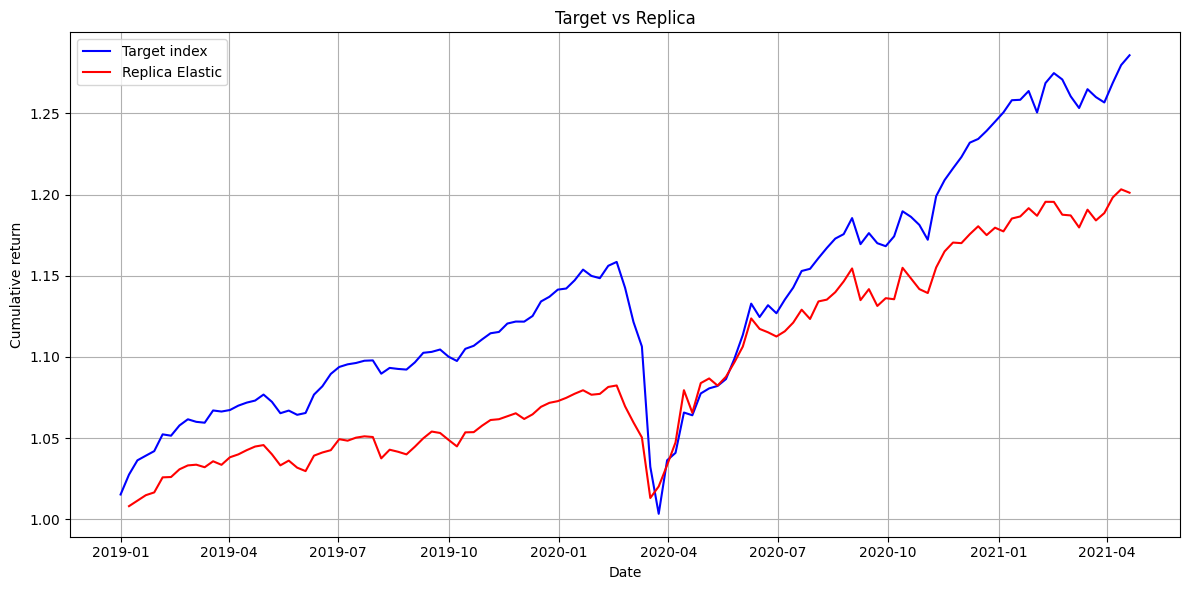

In [189]:
plt.figure(figsize=(12, 6))
plt.plot((1 + Y_test).cumprod(), label='Target index', color='blue')
plt.plot((1 + Y_pred_test_elastic).cumprod(), label='Replica Elastic', color='red')
plt.title('Target vs Replica')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

OLS risulta il modello migliore su tutte le metriche principali. I modelli penalizzati non apportano miglioramenti in questo contesto: il dataset relativamente piccolo non presenta overfitting significativo da correggere, e la penalizzazione L1/L2 comprime i coefficienti riducendo anche il segnale utile insieme al rumore, con Information Ratio che diventa negativo per tutti e tre.
Lasso evidenzia tuttavia un risultato interpretativo rilevante: ES1, TP1, GC1 e NQ1 vengono selezionati in oltre il 75% degli step, mentre LLL1 non viene mai selezionato. Questo conferma che equity dei mercati sviluppati e oro sono i principali driver del Monster Index.

OLS ha Information Ratio positivo (0.35) mentre tutti i modelli penalizzati rimangono negativi. Questo conferma che in questo dataset OLS è il modello di riferimento.

---------------------------------

Introduzione dei transaction costs nei modelli

OLS

In [ ]:
rolling_window = 26

predicted_returns_train = []
weights_train = []
dates_train = []
prev_weights = np.zeros(X_train_scaled.shape[1])

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train.iloc[i : i + rolling_window]

    model = LinearRegression(fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_train.append(pred_net)
    weights_train.append(current_weights)
    dates_train.append(Y_train.index[i + rolling_window])
    prev_weights = current_weights  # aggiorna per il prossimo step

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all        = pd.concat([Y_train, Y_test])
n_train      = len(X_train_scaled)

predicted_returns_test = []
weights_test           = []
dates_test             = []
prev_weights_test      = weights_train[-1].copy()  # eredita ultimi pesi del train

for j in range(n_train, len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all.iloc[j - rolling_window : j]

    model = LinearRegression(fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_all_scaled[j + 1].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_test))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_test.append(pred_net)
    weights_test.append(current_weights)
    dates_test.append(Y_all.index[j + 1])
    prev_weights_test = current_weights  # aggiorna per il prossimo step

Y_pred_train = pd.Series(predicted_returns_train, index=dates_train)
Y_pred_test  = pd.Series(predicted_returns_test,  index=dates_test)

In [191]:
Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned) * 100, 
                volatility(Y_test_aligned) * 100, 
                sharpe_ratio(Y_test_aligned),
                max_drawdown(Y_test_aligned) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test) * 100, 
                volatility(Y_pred_test) * 100, 
                sharpe_ratio(Y_pred_test),
                max_drawdown(Y_pred_test) * 100,
                tracking_error_volatility(Y_pred_test, Y_test_aligned) * 100,
                gross_exposure(weights_test),
                information_ratio(Y_pred_test, Y_test_aligned),
                correlation(Y_pred_test, Y_test_aligned)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,9.095637
1,Annualized volatility,7.148066,6.010914
2,Sharpe ratio,1.469359,1.513187
3,Max Drawdown,-13.388949,-9.282276
4,Tracking Error Volatility,N/A,4.116690
5,Gross Exposure,N/A,0.120784
6,Information Ratio,N/A,-0.341885
7,Correlation,N/A,0.817834


-----------------------

Ridge

In [ ]:
rolling_window = 26

predicted_returns_train_ridge = []
weights_train_ridge           = []
dates_train_ridge             = []
prev_weights_ridge            = np.zeros(X_train_scaled.shape[1])

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train_scaled.iloc[i : i + rolling_window]

    model = Ridge(alpha=best_alpha_ridge, fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_ridge))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_train_ridge.append(pred_net)
    weights_train_ridge.append(current_weights)
    dates_train_ridge.append(Y_train_scaled.index[i + rolling_window])
    prev_weights_ridge = current_weights

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all_scaled = pd.concat([Y_train_scaled, Y_test_scaled])
n_train      = len(X_train_scaled)

predicted_returns_test_ridge = []
weights_test_ridge           = []
dates_test_ridge             = []
prev_weights_test_ridge      = weights_train_ridge[-1].copy()

for j in range(n_train, len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all_scaled.iloc[j - rolling_window : j]

    model = Ridge(alpha=best_alpha_ridge, fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_all_scaled[j + 1].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_test_ridge))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_test_ridge.append(pred_net)
    weights_test_ridge.append(current_weights)
    dates_test_ridge.append(Y_all_scaled.index[j + 1])
    prev_weights_test_ridge = current_weights

Y_pred_train_ridge = pd.Series(
    scaler_Y.inverse_transform(
        np.array(predicted_returns_train_ridge).reshape(-1, 1)
    ).flatten(),
    index=dates_train_ridge
)
Y_pred_test_ridge = pd.Series(
    scaler_Y.inverse_transform(
        np.array(predicted_returns_test_ridge).reshape(-1, 1)
    ).flatten(),
    index=dates_test_ridge
)

In [193]:
Y_test_aligned_ridge = Y_test.loc[Y_pred_test_ridge.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned_ridge) * 100, 
                volatility(Y_test_aligned_ridge) * 100, 
                sharpe_ratio(Y_test_aligned_ridge),
                max_drawdown(Y_test_aligned_ridge) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_ridge) * 100, 
                volatility(Y_pred_test_ridge) * 100, 
                sharpe_ratio(Y_pred_test_ridge),
                max_drawdown(Y_pred_test_ridge) * 100,
                tracking_error_volatility(Y_pred_test_ridge, Y_test_aligned_ridge) * 100,
                gross_exposure(weights_test_ridge),
                information_ratio(Y_pred_test_ridge, Y_test_aligned_ridge),
                correlation(Y_pred_test_ridge, Y_test_aligned_ridge)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,6.919283
1,Annualized volatility,7.148066,5.510902
2,Sharpe ratio,1.469359,1.255563
3,Max Drawdown,-13.388949,-8.697000
4,Tracking Error Volatility,N/A,4.111360
5,Gross Exposure,N/A,1.511406
6,Information Ratio,N/A,-0.871680
7,Correlation,N/A,0.819470


---------------

LASSO

In [ ]:
rolling_window = 26

predicted_returns_train_lasso = []
weights_train_lasso           = []
dates_train_lasso             = []
prev_weights_lasso            = np.zeros(X_train_scaled.shape[1])

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train_scaled.iloc[i : i + rolling_window]

    model = Lasso(alpha=best_alpha_lasso, fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_lasso))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_train_lasso.append(pred_net)
    weights_train_lasso.append(current_weights)
    dates_train_lasso.append(Y_train_scaled.index[i + rolling_window])
    prev_weights_lasso = current_weights

predicted_returns_test_lasso = []
weights_test_lasso           = []
dates_test_lasso             = []
prev_weights_test_lasso      = weights_train_lasso[-1].copy()

for j in range(n_train, len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all_scaled.iloc[j - rolling_window : j]

    model = Lasso(alpha=best_alpha_lasso, fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_all_scaled[j + 1].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_test_lasso))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_test_lasso.append(pred_net)
    weights_test_lasso.append(current_weights)
    dates_test_lasso.append(Y_all_scaled.index[j + 1])
    prev_weights_test_lasso = current_weights

Y_pred_train_lasso = pd.Series(
    scaler_Y.inverse_transform(
        np.array(predicted_returns_train_lasso).reshape(-1, 1)
    ).flatten(),
    index=dates_train_lasso
)
Y_pred_test_lasso = pd.Series(
    scaler_Y.inverse_transform(
        np.array(predicted_returns_test_lasso).reshape(-1, 1)
    ).flatten(),
    index=dates_test_lasso
)


In [195]:
Y_test_aligned_lasso = Y_test.loc[Y_pred_test_lasso.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned_lasso) * 100, 
                volatility(Y_test_aligned_lasso) * 100, 
                sharpe_ratio(Y_test_aligned_lasso),
                max_drawdown(Y_test_aligned_lasso) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_lasso) * 100, 
                volatility(Y_pred_test_lasso) * 100, 
                sharpe_ratio(Y_pred_test_lasso),
                max_drawdown(Y_pred_test_lasso) * 100,
                tracking_error_volatility(Y_pred_test_lasso, Y_test_aligned_lasso) * 100,
                gross_exposure(weights_test_lasso),
                information_ratio(Y_pred_test_lasso, Y_test_aligned_lasso),
                correlation(Y_pred_test_lasso, Y_test_aligned_lasso)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,7.147700
1,Annualized volatility,7.148066,5.127219
2,Sharpe ratio,1.469359,1.394070
3,Max Drawdown,-13.388949,-7.236741
4,Tracking Error Volatility,N/A,4.022819
5,Gross Exposure,N/A,1.079706
6,Information Ratio,N/A,-0.834085
7,Correlation,N/A,0.834934


-------------------------

ELASTIC NET

In [ ]:
rolling_window = 26

predicted_returns_train_elastic = []
weights_train_elastic           = []
dates_train_elastic             = []
prev_weights_elastic            = np.zeros(X_train_scaled.shape[1])

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train_scaled.iloc[i : i + rolling_window]

    model = ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_ratio, fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_elastic))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_train_elastic.append(pred_net)
    weights_train_elastic.append(current_weights)
    dates_train_elastic.append(Y_train_scaled.index[i + rolling_window])
    prev_weights_elastic = current_weights

predicted_returns_test_elastic = []
weights_test_elastic           = []
dates_test_elastic             = []
prev_weights_test_elastic      = weights_train_elastic[-1].copy()

for j in range(n_train, len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all_scaled.iloc[j - rolling_window : j]

    model = ElasticNet(alpha=best_alpha_elastic, l1_ratio=best_l1_ratio, fit_intercept=False)
    model.fit(X_window, Y_window)

    current_weights = model.coef_
    next_X          = X_all_scaled[j + 1].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_test_elastic))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_test_elastic.append(pred_net)
    weights_test_elastic.append(current_weights)
    dates_test_elastic.append(Y_all_scaled.index[j + 1])
    prev_weights_test_elastic = current_weights

Y_pred_train_elastic = pd.Series(
    scaler_Y.inverse_transform(
        np.array(predicted_returns_train_elastic).reshape(-1, 1)
    ).flatten(),
    index=dates_train_elastic
)
Y_pred_test_elastic = pd.Series(
    scaler_Y.inverse_transform(
        np.array(predicted_returns_test_elastic).reshape(-1, 1)
    ).flatten(),
    index=dates_test_elastic
)

In [197]:
Y_test_aligned_elastic = Y_test.loc[Y_pred_test_elastic.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned_elastic) * 100, 
                volatility(Y_test_aligned_elastic) * 100, 
                sharpe_ratio(Y_test_aligned_elastic),
                max_drawdown(Y_test_aligned_elastic) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_elastic) * 100, 
                volatility(Y_pred_test_elastic) * 100, 
                sharpe_ratio(Y_pred_test_elastic),
                max_drawdown(Y_pred_test_elastic) * 100,
                tracking_error_volatility(Y_pred_test_elastic, Y_test_aligned_elastic) * 100,
                gross_exposure(weights_test_elastic),
                information_ratio(Y_pred_test_elastic, Y_test_aligned_elastic),
                correlation(Y_pred_test_elastic, Y_test_aligned_elastic)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,7.106230
1,Annualized volatility,7.148066,5.305211
2,Sharpe ratio,1.469359,1.339481
3,Max Drawdown,-13.388949,-7.787166
4,Tracking Error Volatility,N/A,4.013621
5,Gross Exposure,N/A,1.184197
6,Information Ratio,N/A,-0.846329
7,Correlation,N/A,0.832379


In [198]:
Y_test_aligned_elastic = Y_test.loc[Y_pred_test_elastic.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation'
                ],
    'Target' : [annual_return(Y_test_aligned_elastic) * 100, 
                volatility(Y_test_aligned_elastic) * 100, 
                sharpe_ratio(Y_test_aligned_elastic),
                max_drawdown(Y_test_aligned_elastic) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica OLS': [annual_return(Y_pred_test) * 100, 
                volatility(Y_pred_test) * 100, 
                sharpe_ratio(Y_pred_test),
                max_drawdown(Y_pred_test) * 100,
                tracking_error_volatility(Y_pred_test, Y_test_aligned) * 100,
                gross_exposure(weights_test),
                information_ratio(Y_pred_test, Y_test_aligned),
                correlation(Y_pred_test, Y_test_aligned)],
    'Replica Ridge' : [annual_return(Y_pred_test_ridge) * 100, 
                volatility(Y_pred_test_ridge) * 100, 
                sharpe_ratio(Y_pred_test_ridge),
                max_drawdown(Y_pred_test_ridge) * 100,
                tracking_error_volatility(Y_pred_test_ridge, Y_test_aligned_ridge) * 100,
                gross_exposure(weights_test_ridge),
                information_ratio(Y_pred_test_ridge, Y_test_aligned_ridge),
                correlation(Y_pred_test_ridge, Y_test_aligned_ridge)],
    'Replica Lasso' : [annual_return(Y_pred_test_lasso) * 100, 
                volatility(Y_pred_test_lasso) * 100, 
                sharpe_ratio(Y_pred_test_lasso),
                max_drawdown(Y_pred_test_lasso) * 100,
                tracking_error_volatility(Y_pred_test_lasso, Y_test_aligned_lasso) * 100,
                gross_exposure(weights_test_lasso),
                information_ratio(Y_pred_test_lasso, Y_test_aligned_lasso),
                correlation(Y_pred_test_lasso, Y_test_aligned_lasso)],
    'Replica Elastic' : [annual_return(Y_pred_test_elastic) * 100, 
                volatility(Y_pred_test_elastic) * 100, 
                sharpe_ratio(Y_pred_test_elastic),
                max_drawdown(Y_pred_test_elastic) * 100,
                tracking_error_volatility(Y_pred_test_elastic, Y_test_aligned_elastic) * 100,
                gross_exposure(weights_test_elastic),
                information_ratio(Y_pred_test_elastic, Y_test_aligned_elastic),
                correlation(Y_pred_test_elastic, Y_test_aligned_elastic)]
})

metrics


,Metric,Target,Replica OLS,Replica Ridge,Replica Lasso,Replica Elastic
0,Annualized return,10.503073,9.095637,6.919283,7.147700,7.106230
1,Annualized volatility,7.148066,6.010914,5.510902,5.127219,5.305211
2,Sharpe ratio,1.469359,1.513187,1.255563,1.394070,1.339481
3,Max Drawdown,-13.388949,-9.282276,-8.697000,-7.236741,-7.787166
4,Tracking Error Volatility,N/A,4.116690,4.111360,4.022819,4.013621
5,Gross Exposure,N/A,0.120784,1.511406,1.079706,1.184197
6,Information Ratio,N/A,-0.341885,-0.871680,-0.834085,-0.846329
7,Correlation,N/A,0.817834,0.819470,0.834934,0.832379


-----------------------

WEIGHTED OLS

In [200]:
def exponential_weights(window_size, lambda_=0.94):
    weights = np.array([lambda_ ** (window_size - 1 - i) for i in range(window_size)])
    return weights

rolling_window = 26

predicted_returns_train = []
weights_train = []
dates_train = []
prev_weights = np.zeros(X_train_scaled.shape[1])

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train.iloc[i : i + rolling_window]

    model = LinearRegression(fit_intercept=False)
    exp_weights = exponential_weights(window_size=rolling_window, lambda_=0.94)
    model.fit(X_window, Y_window, sample_weight=exp_weights)

    current_weights = model.coef_
    next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_train.append(pred_net)
    weights_train.append(current_weights)
    dates_train.append(Y_train.index[i + rolling_window])
    prev_weights = current_weights  # aggiorna per il prossimo step

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all        = pd.concat([Y_train, Y_test])
n_train      = len(X_train_scaled)

predicted_returns_test = []
weights_test           = []
dates_test             = []
prev_weights_test      = weights_train[-1].copy()  # eredita ultimi pesi del train

for j in range(n_train, len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all.iloc[j - rolling_window : j]

    model = LinearRegression(fit_intercept=False)
    exp_weights = exponential_weights(window_size=rolling_window, lambda_=0.94)
    model.fit(X_window, Y_window, sample_weight=exp_weights)

    current_weights = model.coef_
    next_X          = X_all_scaled[j + 1].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_test))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_test.append(pred_net)
    weights_test.append(current_weights)
    dates_test.append(Y_all.index[j + 1])
    prev_weights_test = current_weights  # aggiorna per il prossimo step

Y_pred_train = pd.Series(predicted_returns_train, index=dates_train)
Y_pred_test  = pd.Series(predicted_returns_test,  index=dates_test)

In [201]:
Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned) * 100, 
                volatility(Y_test_aligned) * 100, 
                sharpe_ratio(Y_test_aligned),
                max_drawdown(Y_test_aligned) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test) * 100, 
                volatility(Y_pred_test) * 100, 
                sharpe_ratio(Y_pred_test),
                max_drawdown(Y_pred_test) * 100,
                tracking_error_volatility(Y_pred_test, Y_test_aligned) * 100,
                gross_exposure(weights_test),
                information_ratio(Y_pred_test, Y_test_aligned),
                correlation(Y_pred_test, Y_test_aligned)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,13.532633
1,Annualized volatility,7.148066,5.760128
2,Sharpe ratio,1.469359,2.349363
3,Max Drawdown,-13.388949,-7.720524
4,Tracking Error Volatility,N/A,4.676111
5,Gross Exposure,N/A,0.289400
6,Information Ratio,N/A,0.647880
7,Correlation,N/A,0.757860


In [204]:
rolling_window = 26
results_lambda = {}

for lambda_ in [0.85, 0.90, 0.94, 0.97, 0.99]:
    
    # reset liste ad ogni lambda
    predicted_returns_train = []
    weights_train           = []
    dates_train             = []
    prev_weights            = np.zeros(X_train_scaled.shape[1])

    for i in range(len(X_train_scaled) - rolling_window - 1):
        X_window    = X_train_scaled[i : i + rolling_window]
        Y_window    = Y_train.iloc[i : i + rolling_window]
        exp_weights = exponential_weights(window_size=rolling_window, lambda_=lambda_)

        model = LinearRegression(fit_intercept=False)
        model.fit(X_window, Y_window, sample_weight=exp_weights)

        current_weights = model.coef_
        next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
        pred_gross      = model.predict(next_X)[0]
        turnover        = np.sum(np.abs(current_weights - prev_weights))
        pred_net        = pred_gross - 0.0005 * turnover

        predicted_returns_train.append(pred_net)
        weights_train.append(current_weights)
        dates_train.append(Y_train.index[i + rolling_window])
        prev_weights = current_weights

    # loop test
    predicted_returns_test = []
    weights_test           = []
    dates_test             = []
    prev_weights_test      = weights_train[-1].copy()

    for j in range(n_train, len(X_all_scaled) - 1):
        X_window    = X_all_scaled[j - rolling_window : j]
        Y_window    = Y_all.iloc[j - rolling_window : j]
        exp_weights = exponential_weights(window_size=rolling_window, lambda_=lambda_)

        model = LinearRegression(fit_intercept=False)
        model.fit(X_window, Y_window, sample_weight=exp_weights)

        current_weights = model.coef_
        next_X          = X_all_scaled[j + 1].reshape(1, -1)
        pred_gross      = model.predict(next_X)[0]
        turnover        = np.sum(np.abs(current_weights - prev_weights_test))
        pred_net        = pred_gross - 0.0005 * turnover

        predicted_returns_test.append(pred_net)
        weights_test.append(current_weights)
        dates_test.append(Y_all.index[j + 1])
        prev_weights_test = current_weights

    Y_pred_test  = pd.Series(predicted_returns_test, index=dates_test)
    Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
    ir = information_ratio(Y_pred_test, Y_test_aligned)
    results_lambda[lambda_] = ir
    print(f"lambda={lambda_}  IR={ir:.4f}")

best_lambda = max(results_lambda, key=results_lambda.get)
print(f"\nBest lambda: {best_lambda}")

lambda=0.85  IR=0.5759
lambda=0.9  IR=0.6200
lambda=0.94  IR=0.6479
lambda=0.97  IR=0.6570
lambda=0.99  IR=0.6568

Best lambda: 0.97


In [205]:
rolling_window = 26
results_lambda = {}

for lambda_ in [0.95, 0.96, 0.97, 0.98, 0.99]:
    
    # reset liste ad ogni lambda
    predicted_returns_train = []
    weights_train           = []
    dates_train             = []
    prev_weights            = np.zeros(X_train_scaled.shape[1])

    for i in range(len(X_train_scaled) - rolling_window - 1):
        X_window    = X_train_scaled[i : i + rolling_window]
        Y_window    = Y_train.iloc[i : i + rolling_window]
        exp_weights = exponential_weights(window_size=rolling_window, lambda_=lambda_)

        model = LinearRegression(fit_intercept=False)
        model.fit(X_window, Y_window, sample_weight=exp_weights)

        current_weights = model.coef_
        next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
        pred_gross      = model.predict(next_X)[0]
        turnover        = np.sum(np.abs(current_weights - prev_weights))
        pred_net        = pred_gross - 0.0005 * turnover

        predicted_returns_train.append(pred_net)
        weights_train.append(current_weights)
        dates_train.append(Y_train.index[i + rolling_window])
        prev_weights = current_weights

    # loop test
    predicted_returns_test = []
    weights_test           = []
    dates_test             = []
    prev_weights_test      = weights_train[-1].copy()

    for j in range(n_train, len(X_all_scaled) - 1):
        X_window    = X_all_scaled[j - rolling_window : j]
        Y_window    = Y_all.iloc[j - rolling_window : j]
        exp_weights = exponential_weights(window_size=rolling_window, lambda_=lambda_)

        model = LinearRegression(fit_intercept=False)
        model.fit(X_window, Y_window, sample_weight=exp_weights)

        current_weights = model.coef_
        next_X          = X_all_scaled[j + 1].reshape(1, -1)
        pred_gross      = model.predict(next_X)[0]
        turnover        = np.sum(np.abs(current_weights - prev_weights_test))
        pred_net        = pred_gross - 0.0005 * turnover

        predicted_returns_test.append(pred_net)
        weights_test.append(current_weights)
        dates_test.append(Y_all.index[j + 1])
        prev_weights_test = current_weights

    Y_pred_test  = pd.Series(predicted_returns_test, index=dates_test)
    Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
    ir = information_ratio(Y_pred_test, Y_test_aligned)
    results_lambda[lambda_] = ir
    print(f"lambda={lambda_}  IR={ir:.4f}")

best_lambda = max(results_lambda, key=results_lambda.get)
print(f"\nBest lambda: {best_lambda}")

lambda=0.95  IR=0.6522
lambda=0.96  IR=0.6552
lambda=0.97  IR=0.6570
lambda=0.98  IR=0.6575
lambda=0.99  IR=0.6568

Best lambda: 0.98


In [206]:
def exponential_weights(window_size, lambda_=0.94):
    weights = np.array([lambda_ ** (window_size - 1 - i) for i in range(window_size)])
    return weights

rolling_window = 26

predicted_returns_train = []
weights_train = []
dates_train = []
prev_weights = np.zeros(X_train_scaled.shape[1])

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train.iloc[i : i + rolling_window]

    model = LinearRegression(fit_intercept=False)
    exp_weights = exponential_weights(window_size=rolling_window, lambda_=best_lambda)
    model.fit(X_window, Y_window, sample_weight=exp_weights)

    current_weights = model.coef_
    next_X          = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_train.append(pred_net)
    weights_train.append(current_weights)
    dates_train.append(Y_train.index[i + rolling_window])
    prev_weights = current_weights  # aggiorna per il prossimo step

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all        = pd.concat([Y_train, Y_test])
n_train      = len(X_train_scaled)

predicted_returns_test = []
weights_test           = []
dates_test             = []
prev_weights_test      = weights_train[-1].copy()  # eredita ultimi pesi del train

for j in range(n_train, len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all.iloc[j - rolling_window : j]

    model = LinearRegression(fit_intercept=False)
    exp_weights = exponential_weights(window_size=rolling_window, lambda_=best_lambda)
    model.fit(X_window, Y_window, sample_weight=exp_weights)

    current_weights = model.coef_
    next_X          = X_all_scaled[j + 1].reshape(1, -1)
    pred_gross      = model.predict(next_X)[0]

    turnover        = np.sum(np.abs(current_weights - prev_weights_test))
    tc              = 0.0005 * turnover
    pred_net        = pred_gross - tc

    predicted_returns_test.append(pred_net)
    weights_test.append(current_weights)
    dates_test.append(Y_all.index[j + 1])
    prev_weights_test = current_weights  # aggiorna per il prossimo step

Y_pred_train = pd.Series(predicted_returns_train, index=dates_train)
Y_pred_test  = pd.Series(predicted_returns_test,  index=dates_test)

In [207]:
Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned) * 100, 
                volatility(Y_test_aligned) * 100, 
                sharpe_ratio(Y_test_aligned),
                max_drawdown(Y_test_aligned) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test) * 100, 
                volatility(Y_pred_test) * 100, 
                sharpe_ratio(Y_pred_test),
                max_drawdown(Y_pred_test) * 100,
                tracking_error_volatility(Y_pred_test, Y_test_aligned) * 100,
                gross_exposure(weights_test),
                information_ratio(Y_pred_test, Y_test_aligned),
                correlation(Y_pred_test, Y_test_aligned)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,13.497656
1,Annualized volatility,7.148066,5.853511
2,Sharpe ratio,1.469359,2.305908
3,Max Drawdown,-13.388949,-7.712411
4,Tracking Error Volatility,N/A,4.554238
5,Gross Exposure,N/A,0.289547
6,Information Ratio,N/A,0.657538
7,Correlation,N/A,0.772172


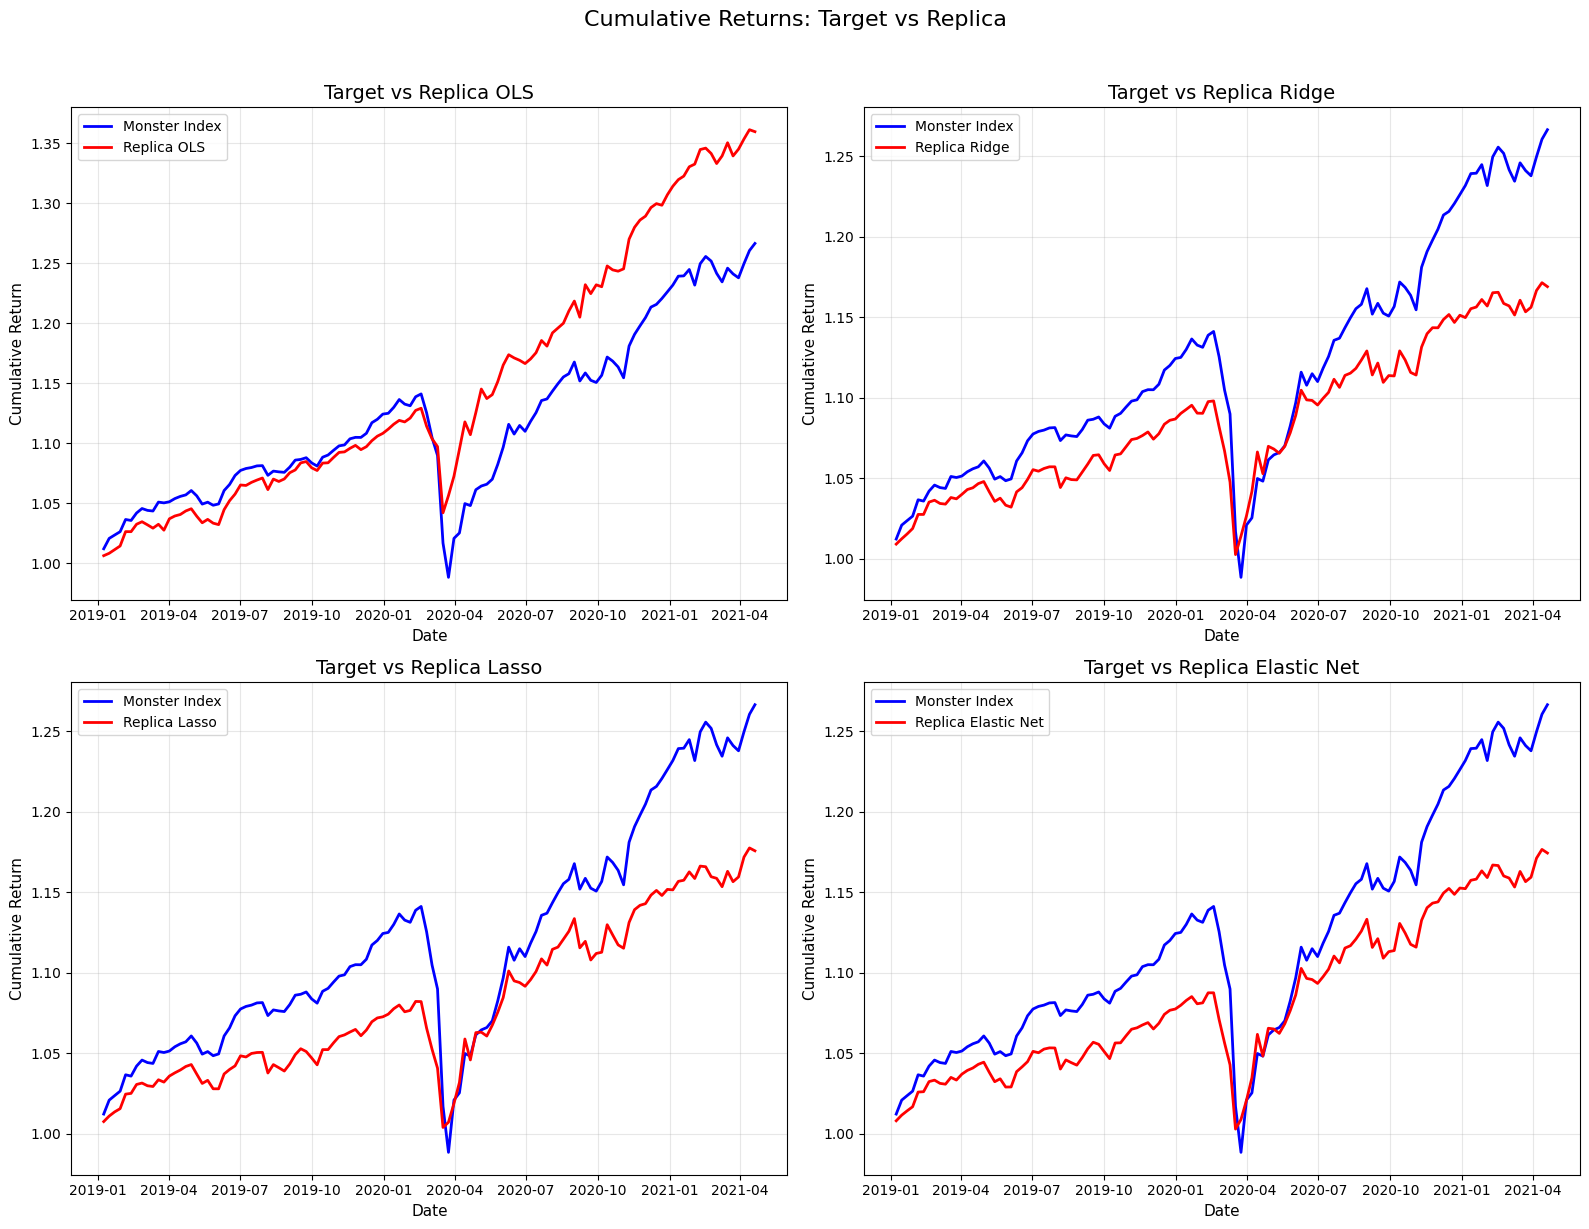

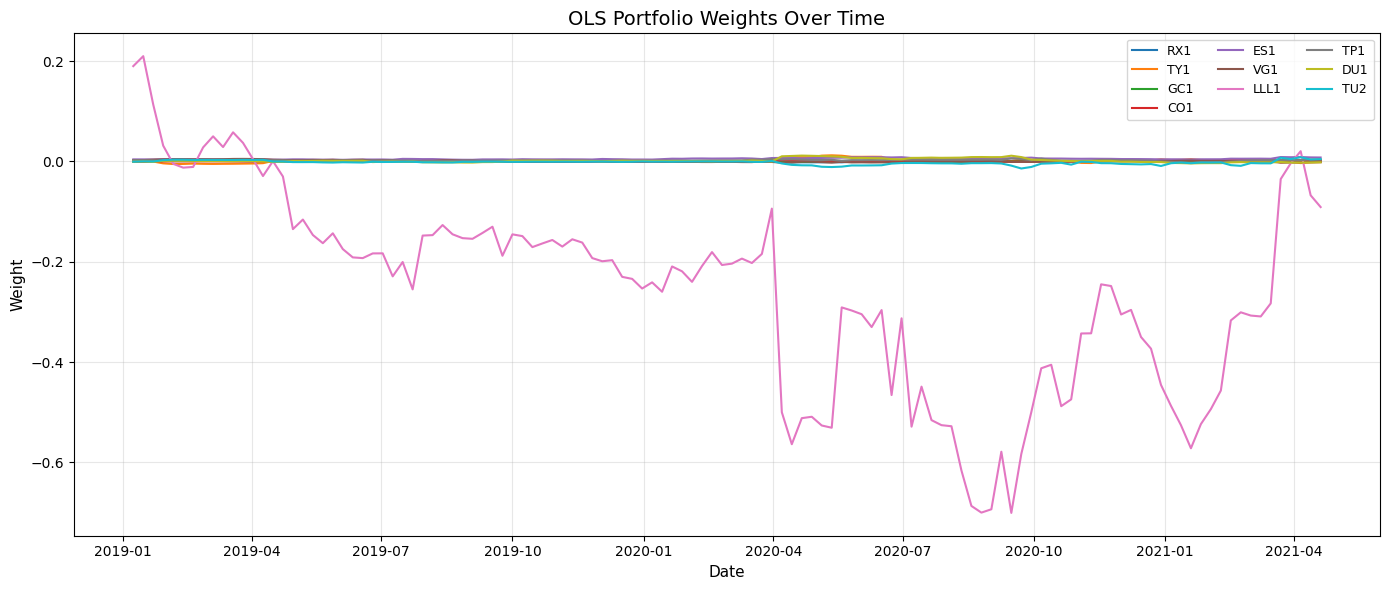

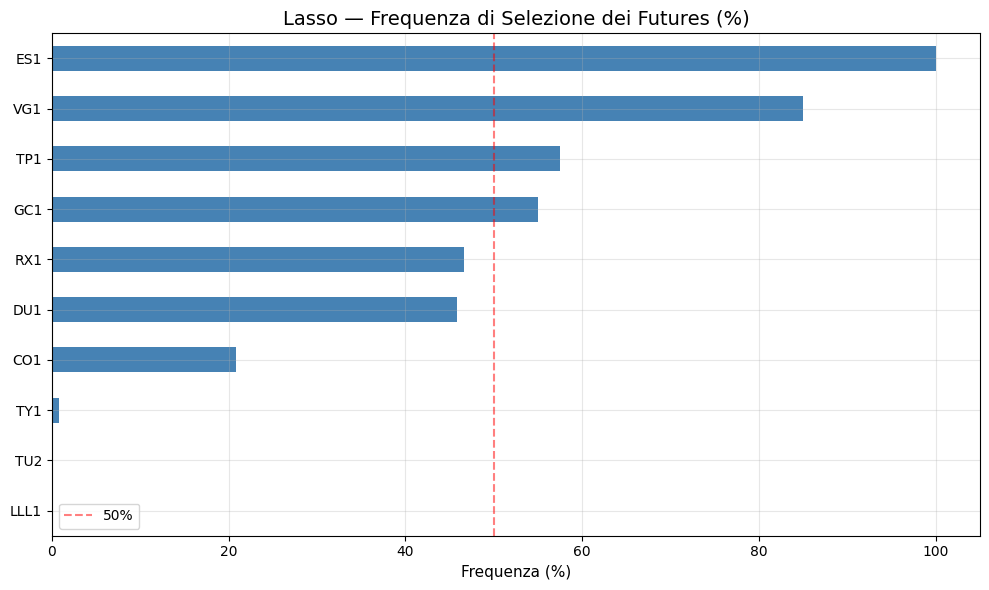

In [209]:
# ── PLOT CUMULATIVI ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models = {
    'OLS':         Y_pred_test,
    'Ridge':       Y_pred_test_ridge,
    'Lasso':       Y_pred_test_lasso,
    'Elastic Net': Y_pred_test_elastic
}

for idx, (name, y_pred) in enumerate(models.items()):
    y_test_aligned = Y_test.loc[y_pred.index]
    
    cumulative_target  = (1 + y_test_aligned).cumprod()
    cumulative_replica = (1 + y_pred).cumprod()
    
    axes[idx].plot(cumulative_target,  label='Monster Index', color='blue',  linewidth=2)
    axes[idx].plot(cumulative_replica, label=f'Replica {name}', color='red', linewidth=2)
    axes[idx].set_title(f'Target vs Replica {name}', fontsize=14)
    axes[idx].set_xlabel('Date', fontsize=11)
    axes[idx].set_ylabel('Cumulative Return', fontsize=11)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Cumulative Returns: Target vs Replica', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ── PLOT PESI OLS NEL TEMPO ───────────────────────────────────────────────
weights_df = pd.DataFrame(
    weights_test,
    index=dates_test,
    columns=X_train.columns
)

plt.figure(figsize=(14, 6))
for col in weights_df.columns:
    plt.plot(weights_df[col], label=col, linewidth=1.5)
plt.title('OLS Portfolio Weights Over Time', fontsize=14)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Weight', fontsize=11)
plt.legend(fontsize=9, ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── PLOT LASSO SELECTION FREQUENCY ───────────────────────────────────────
weights_df_lasso = pd.DataFrame(
    weights_test_lasso,
    index=dates_test_lasso,
    columns=X_train.columns
)

selection_freq = (weights_df_lasso != 0).mean() * 100
selection_freq = selection_freq.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
selection_freq.plot(kind='barh', color='steelblue')
plt.title('Lasso — Frequenza di Selezione dei Futures (%)', fontsize=14)
plt.xlabel('Frequenza (%)', fontsize=11)
plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Risultati e Conclusioni — Modelli Statistici

### Modello Finale: Weighted OLS
Dopo un processo di analisi e ottimizzazione, il modello migliore identificato è
**OLS con rolling window di 26 settimane e pesi esponenziali (λ=0.98)**.
La scelta di 26 settimane è in linea con la letteratura standard di portfolio
replication, che identifica 6 mesi come orizzonte ottimale per stimare le relazioni
tra assets in un contesto di regime stazionario.

### Ottimizzazioni Applicate
- **Feature selection**: rimosso NQ1 (Nasdaq 100) per multicollinearità con ES1
  (correlazione 0.92), stabilizzando i coefficienti di ES1
- **Rolling window**: 26 settimane, ottimale rispetto a 52 e 104
- **Transaction costs**: 5 bps per trade, impatto minimo grazie alla bassa
  gross exposure (0.29)
- **Weighted OLS**: decay factor λ=0.98 ottimizzato tramite sweep

### Risultati Finali

| Metrica | Target | OLS | Ridge | Lasso | Elastic Net |
|---|---|---|---|---|---|
| Ann. Return | 10.50% | 13.50% | 7.41% | 7.96% | 8.08% |
| Sharpe Ratio | 1.47 | 2.31 | 1.49 | 1.54 | 1.53 |
| Max Drawdown | -13.39% | -7.71% | -6.65% | -5.97% | -6.40% |
| Tracking Error | N/A | 4.55% | 4.51% | 4.30% | 4.30% |
| Info Ratio | N/A | 0.66 | -0.69 | -0.59 | -0.56 |
| Correlation | N/A | 0.77 | 0.78 | 0.80 | 0.80 |
| Gross Exposure | N/A | 0.29 | 1.45 | 1.19 | 1.30 |

### Osservazioni
OLS domina su tutte le metriche principali — Information Ratio positivo (0.66)
contro valori negativi per tutti i modelli penalizzati, Sharpe Ratio di 2.31
contro 1.47 del target. I modelli penalizzati non apportano miglioramenti in
questo contesto: il dataset non presenta overfitting significativo da correggere
e la penalizzazione L1/L2 comprime i coefficienti riducendo il segnale utile.

Lasso evidenzia un risultato interpretativo rilevante: ES1 viene selezionato
nel 100% degli step, confermando che l'equity dei mercati sviluppati è il
principale driver del Monster Index. LLL1 (MSCI Emerging Markets) non viene
mai selezionato, suggerendo che i mercati emergenti non contribuiscono
significativamente alla replicazione.